In [85]:
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [86]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=30)

In [87]:
df = pd.DataFrame(X , columns=[f"Feature {i + 1}" for i in range(X.shape[1])])
df["Target"] = y

In [88]:
df.sample(5)

,Feature 1,Feature 2,Target
9,-5.356326,0.751528,0
7,0.709629,0.806267,1
47,-4.769829,-0.784709,0
40,-4.722497,-0.645846,0
72,1.696306,-0.303653,1


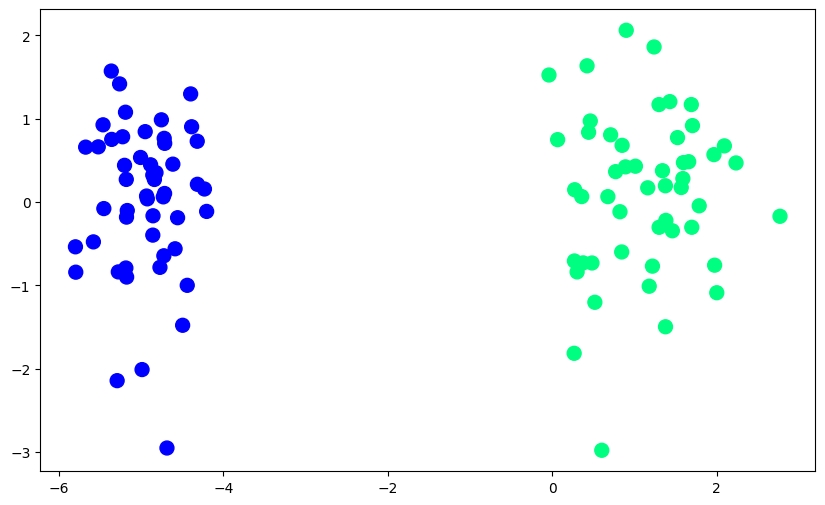

In [89]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [90]:
X.shape

(100, 2)

In [91]:
y.shape

(100,)

In [126]:
class Perceptron :
    def __init__(self, learning_rate, epochs):
        self.lr = learning_rate
        self.epochs = epochs
    def sigmoid(self,z):
        return 1 / (1 + np.exp(-z))
    def fit(self, X, y):
        X = np.insert(X, 0 , 1 , axis = 1)
        weights = np.ones(X.shape[1])
        for i in range(self.epochs):
            j = np.random.randint(0, X.shape[0])
            z = np.dot(X[j] , weights)
            y_cap = self.sigmoid(z)
            weights = weights + self.lr * (y[j] - y_cap) * X[j]
        return weights[0], weights[1:]
    def predict(self,X,intercept, coeff):
        z = np.dot(X , coeff) + intercept
        p = self.sigmoid(z)
        y_cap = (p >= 0.5).astype(int)
        return y_cap , p

In [93]:
X

array([[ 0.82321545, -0.11697552],
       [ 0.37514771, -0.73115232],
       [ 0.26947761, -0.7081059 ],
       [-4.98744874, -2.01199214],
       [ 0.4231285 ,  1.63493163],
       [-4.2289949 ,  0.15599044],
       [-5.18865382,  1.07782053],
       [ 0.7096287 ,  0.80626713],
       [ 0.06531501,  0.74859527],
       [-5.3563263 ,  0.75152794],
       [-5.17487315, -0.90114581],
       [-5.17644221, -0.1815243 ],
       [ 0.60202649, -2.98092432],
       [ 1.42960231,  1.20500136],
       [-5.22359581,  0.78302407],
       [ 1.01127528,  0.42968688],
       [ 0.48288133, -0.73229726],
       [-5.27614308, -0.83930476],
       [ 0.44163889,  0.83727062],
       [-5.167179  , -0.10255323],
       [-5.67316396,  0.65867001],
       [-5.4617787 ,  0.92649819],
       [-4.71348919,  0.10216193],
       [ 2.2344006 ,  0.46886454],
       [-4.61308761,  0.45432938],
       [ 1.2379403 ,  1.8613386 ],
       [-5.18419324, -0.79255991],
       [-4.43807529, -1.0004391 ],
       [-5.79725951,

In [94]:
np.insert(X, 0 , 1 , axis = 1)

array([[ 1.        ,  0.82321545, -0.11697552],
       [ 1.        ,  0.37514771, -0.73115232],
       [ 1.        ,  0.26947761, -0.7081059 ],
       [ 1.        , -4.98744874, -2.01199214],
       [ 1.        ,  0.4231285 ,  1.63493163],
       [ 1.        , -4.2289949 ,  0.15599044],
       [ 1.        , -5.18865382,  1.07782053],
       [ 1.        ,  0.7096287 ,  0.80626713],
       [ 1.        ,  0.06531501,  0.74859527],
       [ 1.        , -5.3563263 ,  0.75152794],
       [ 1.        , -5.17487315, -0.90114581],
       [ 1.        , -5.17644221, -0.1815243 ],
       [ 1.        ,  0.60202649, -2.98092432],
       [ 1.        ,  1.42960231,  1.20500136],
       [ 1.        , -5.22359581,  0.78302407],
       [ 1.        ,  1.01127528,  0.42968688],
       [ 1.        ,  0.48288133, -0.73229726],
       [ 1.        , -5.27614308, -0.83930476],
       [ 1.        ,  0.44163889,  0.83727062],
       [ 1.        , -5.167179  , -0.10255323],
       [ 1.        , -5.67316396,  0.658

In [95]:
X.shape

(100, 2)

In [96]:
np.ones(X.shape[1] + 1)

array([1., 1., 1.])

In [134]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=13)

In [127]:
ourPerceptron = Perceptron(learning_rate=0.01, epochs=100)

In [135]:
intercept , coeff = ourPerceptron.fit(X_train,y_train)

In [136]:
y_cap , p = ourPerceptron.predict(X_test,intercept, coeff)

In [137]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_cap)

0.95

In [131]:
y_cap

array([1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1])

In [132]:
p

array([8.62688624e-01, 6.81215153e-01, 6.60303014e-01, 1.69727306e-03,
       9.55289339e-01, 2.99218954e-02, 2.50489621e-02, 9.30227102e-01,
       8.61072561e-01, 1.54157874e-02, 3.95903170e-03, 7.80339944e-03,
       2.44320351e-01, 9.77332609e-01, 1.83358838e-02, 9.28580531e-01,
       7.06237174e-01, 3.75551766e-03, 9.10835516e-01, 8.49236906e-03,
       1.00031511e-02, 1.61927422e-02, 1.68784312e-02, 9.81151468e-01,
       2.61076942e-02, 9.84877839e-01, 4.34298635e-03, 8.09012226e-03,
       2.81605478e-03, 1.36447108e-02, 1.72699363e-02, 9.23978959e-01,
       9.32413611e-01, 9.22974476e-01, 7.99004876e-01, 6.40112794e-01,
       5.01976635e-02, 9.73014730e-01, 1.84134535e-02, 9.13314030e-01,
       8.27846538e-03, 2.87651268e-02, 3.67276473e-02, 9.81849190e-01,
       2.40109706e-02, 9.77979543e-01, 9.03570818e-01, 6.89496859e-03,
       4.83664794e-03, 4.60634895e-02, 8.02455259e-01, 8.14734174e-01,
       1.90341285e-02, 9.49620632e-01, 9.80795745e-01, 1.26430808e-02,
      

In [99]:
intercept

np.float64(1.0427770155273253)

In [100]:
coeff

array([1.11140113, 0.94792232])

In [101]:
m = - (coeff[0] / coeff[1])
b = -(intercept / coeff[1])
x = np.linspace(-3,3,100)
y1 = m * x + b

(-3.0, 2.0)

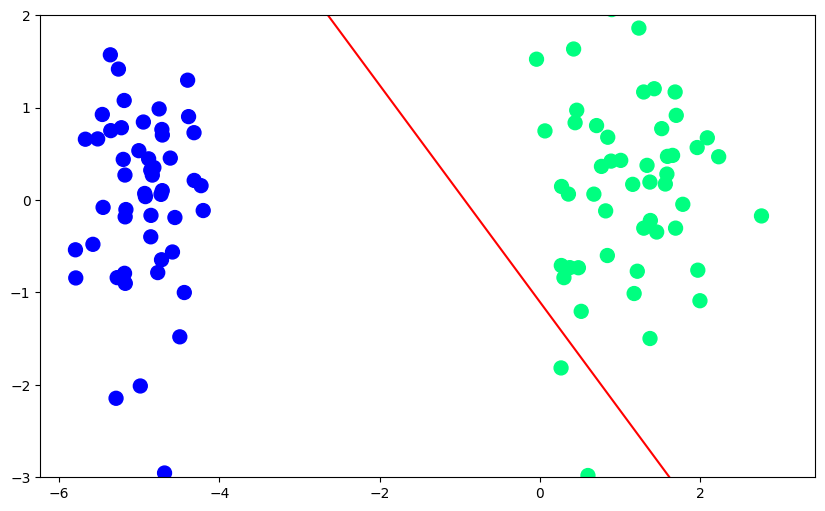

In [102]:
plt.figure(figsize=(10,6))
plt.plot(x,y1,color="red")
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [103]:
x

array([-3.        , -2.93939394, -2.87878788, -2.81818182, -2.75757576,
       -2.6969697 , -2.63636364, -2.57575758, -2.51515152, -2.45454545,
       -2.39393939, -2.33333333, -2.27272727, -2.21212121, -2.15151515,
       -2.09090909, -2.03030303, -1.96969697, -1.90909091, -1.84848485,
       -1.78787879, -1.72727273, -1.66666667, -1.60606061, -1.54545455,
       -1.48484848, -1.42424242, -1.36363636, -1.3030303 , -1.24242424,
       -1.18181818, -1.12121212, -1.06060606, -1.        , -0.93939394,
       -0.87878788, -0.81818182, -0.75757576, -0.6969697 , -0.63636364,
       -0.57575758, -0.51515152, -0.45454545, -0.39393939, -0.33333333,
       -0.27272727, -0.21212121, -0.15151515, -0.09090909, -0.03030303,
        0.03030303,  0.09090909,  0.15151515,  0.21212121,  0.27272727,
        0.33333333,  0.39393939,  0.45454545,  0.51515152,  0.57575758,
        0.63636364,  0.6969697 ,  0.75757576,  0.81818182,  0.87878788,
        0.93939394,  1.        ,  1.06060606,  1.12121212,  1.18

In [104]:
y

array([1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1])